# Invasive alien species records and night-time lights in Finland

This notebook tests whether observations of invasive alien species in Finland are more frequent in
brighter, i.e. more built-up and populated, areas. Night-time light intensity from VIIRS is used as a
proxy for human presence and activity.

**Workflow**

1. Clip the global VIIRS 2024 annual night-time lights composite to Finland.
2. Load the GBIF records of invasive species observations and aggregate them onto the
   night-time light grid (15 arc-seconds) per kingdom: Animalia, Plantae and both combined.
3. Correlate night-time light with the number of records and the number of individuals in every
   pixel that holds at least one record (Pearson on raw and log-transformed values, Spearman with
   bootstrap confidence intervals).
4. Summarise counts by night-time light decile and fit quantile regressions.
5. Compare how often pixels hold any record across night-time light classes (all pixels,
   including those without records).

The input data are not part of this repository. See [Data sources](#Data-sources) at the end.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import rowcol
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Configuration
Paths are relative to this notebook. Place the input files in `DATA_DIR`.

In [2]:
# Input data (see "Data sources" below)
DATA_DIR = Path("data")
NL_FILE = DATA_DIR / "VNL_npp_2024_global_vcmslcfg_v2_c202502261200.average_masked.dat.tif"  # VIIRS VNL v2, 2024
OCC_FILE = DATA_DIR / "invasive.csv"           # GBIF occurrence download (tab-separated despite .csv)
BOUNDARY_FILE = DATA_DIR / "fi_shape" / "fi.shp"  # Finland boundary

# Kingdom groups to analyse
GROUPS = {
    "Animalia": ["Animalia"],
    "Plantae": ["Plantae"],
    "Combined": ["Animalia", "Plantae"],
}
# Count per pixel used in the hexbin and step 5: "records" (number of observations) or
# "individuals" (sum of individualCount). Most occupied pixels hold a single record, so
# "individuals" is the measure that varies enough for boxplots and quantile regression.
FIGURE_MEASURE = "individuals"

QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]
N_BOOT = 1000
SEED = 42

# Outputs
OUT_DIR = Path("output")      # rasters (large, not committed)
FIG_DIR = Path("figures")
RESULTS_DIR = Path("results")
for d in (OUT_DIR, FIG_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)
NL_CLIPPED_FILE = OUT_DIR / "nightlight_2024_finland.tif"

COUNTS_NODATA = -1
rng = np.random.default_rng(SEED)

## 1. Clip night-time lights to Finland
The VIIRS *average_masked* product is in nW cm⁻² sr⁻¹. Background (unlit) pixels are set to 0 in
this product and are kept as valid observations of darkness. Pixels outside Finland become NaN.

In [3]:
boundary = gpd.read_file(BOUNDARY_FILE)
with rasterio.open(NL_FILE) as src:
    boundary = boundary.to_crs(src.crs)
    nl_stack, nl_transform = mask(src, boundary.geometry, crop=True, nodata=np.nan, filled=True)
    nl_crs = src.crs
nl = nl_stack[0].astype("float32")
nl_meta = {"driver": "GTiff", "dtype": "float32", "count": 1, "height": nl.shape[0],
           "width": nl.shape[1], "transform": nl_transform, "crs": nl_crs,
           "nodata": np.nan, "compress": "lzw"}
with rasterio.open(NL_CLIPPED_FILE, "w", **nl_meta) as dst:
    dst.write(nl, 1)

valid = np.isfinite(nl)
lit = valid & (nl > 0)
print(f"Grid: {nl.shape[1]} x {nl.shape[0]} pixels at {nl_transform.a * 3600:.0f} arc-seconds")
print(f"Pixels inside Finland: {valid.sum():,}, of which lit (> 0): {lit.sum():,} ({lit.sum() / valid.sum():.1%})")
print("Lit pixel percentiles [1, 50, 99, max] (nW/cm²/sr):",
      np.round(np.percentile(nl[lit], [1, 50, 99, 100]), 2))

Grid: 2628 x 2464 pixels at 15 arc-seconds
Pixels inside Finland: 3,584,297, of which lit (> 0): 361,711 (10.1%)
Lit pixel percentiles [1, 50, 99, max] (nW/cm²/sr): [5.900000e-01 1.650000e+00 6.321000e+01 1.956844e+04]


## 2. Load invasive species records
Records without an `individualCount` are counted as one individual.

In [4]:
cols = ["gbifID", "kingdom", "species", "individualCount", "decimalLatitude", "decimalLongitude", "year"]
occ = pd.read_csv(OCC_FILE, sep="\t", usecols=cols, low_memory=False)
occ = occ.dropna(subset=["decimalLatitude", "decimalLongitude"])
missing_counts = occ["individualCount"].isna().sum()
occ["individualCount"] = pd.to_numeric(occ["individualCount"], errors="coerce").fillna(1).astype("int64")

print(f"{len(occ):,} records, {occ['species'].nunique()} species, years {occ['year'].min()}-{occ['year'].max()}")
print(f"individualCount missing (set to 1): {missing_counts:,}; max: {occ['individualCount'].max():,}")
print(occ["kingdom"].value_counts(dropna=False).to_string())

7,788 records, 107 species, years 2009-2025
individualCount missing (set to 1): 3,389; max: 100,000
kingdom
Plantae      6222
Animalia     1547
NaN            11
Fungi           7
Chromista       1


## 3. Aggregate records onto the night-time light grid
Each record is assigned to the pixel that contains it. Records outside the Finland boundary
(e.g. offshore) are dropped.

In [5]:
pts = gpd.GeoDataFrame(occ, geometry=gpd.points_from_xy(occ["decimalLongitude"], occ["decimalLatitude"]),
                       crs="EPSG:4326").to_crs(nl_crs)
r, c = (np.asarray(v) for v in rowcol(nl_transform, pts.geometry.x.values, pts.geometry.y.values))
in_grid = (r >= 0) & (r < nl.shape[0]) & (c >= 0) & (c < nl.shape[1])
in_fin = in_grid.copy()
in_fin[in_grid] = valid[r[in_grid], c[in_grid]]
pts, r, c = pts[in_fin], r[in_fin], c[in_fin]
print(f"Records inside Finland: {len(pts):,} (dropped {(~in_fin).sum()})")

counts = {}
for group, kingdoms in GROUPS.items():
    sel = pts["kingdom"].isin(kingdoms).values
    counts[group] = {}
    for measure, weights in (("records", np.ones(sel.sum(), dtype="int64")),
                             ("individuals", pts.loc[sel, "individualCount"].values)):
        grid = np.zeros(nl.shape, dtype="int64")
        np.add.at(grid, (r[sel], c[sel]), weights)
        counts[group][measure] = grid
        with rasterio.open(OUT_DIR / f"invasives_{group.lower()}_{measure}.tif", "w",
                           **(nl_meta | {"dtype": "int32", "nodata": COUNTS_NODATA})) as dst:
            dst.write(np.where(valid, grid, COUNTS_NODATA).astype("int32"), 1)
    print(f"{group}: {sel.sum():,} records in {(counts[group]['records'] > 0).sum():,} pixels")

Records inside Finland: 7,509 (dropped 279)


Animalia: 1,484 records in 973 pixels


Plantae: 6,006 records in 4,452 pixels


Combined: 7,490 records in 5,290 pixels


## 4. Correlation between night-time light and counts
Only pixels with at least one record are used, so the question is: *where species were recorded,
are counts higher in brighter areas?* Both variables are strongly right-skewed, so the rank-based
Spearman ρ is the main measure. Pearson r on raw values is shown for comparison only. The 95 %
confidence interval for ρ comes from a bootstrap of pixels.

In [6]:
def occupied_pairs(group, measure):
    grid = counts[group][measure]
    sel = valid & (grid > 0)
    return nl[sel].astype("float64"), grid[sel].astype("float64")


def spearman_ci(x, y, n_boot=N_BOOT):
    n = x.size
    rhos = [spearmanr(x[idx], y[idx])[0] for idx in (rng.integers(0, n, n) for _ in range(n_boot))]
    return np.nanpercentile(rhos, [2.5, 97.5])


rows = []
for group in GROUPS:
    for measure in ("records", "individuals"):
        x, y = occupied_pairs(group, measure)
        rho, p_rho = spearmanr(x, y)
        lo, hi = spearman_ci(x, y)
        rows.append({
            "group": group, "measure": measure, "n_pixels": x.size,
            "spearman_rho": rho, "rho_ci_low": lo, "rho_ci_high": hi, "spearman_p": p_rho,
            "pearson_r_raw": pearsonr(x, y)[0],
            "pearson_r_log1p": pearsonr(np.log1p(x), np.log1p(y))[0],
        })
corr = pd.DataFrame(rows)
corr.to_csv(RESULTS_DIR / "correlations.csv", index=False)
corr.round(3)

,group,measure,n_pixels,spearman_rho,rho_ci_low,rho_ci_high,spearman_p,pearson_r_raw,pearson_r_log1p
0,Animalia,records,973,0.023,-0.041,0.085,0.475,0.016,0.015
1,Animalia,individuals,973,0.119,0.057,0.183,0.000,-0.001,0.120
2,Plantae,records,4452,0.088,0.060,0.115,0.000,-0.000,0.081
3,Plantae,individuals,4452,0.070,0.040,0.101,0.000,-0.005,0.041
4,Combined,records,5290,0.090,0.065,0.116,0.000,0.001,0.078
5,Combined,individuals,5290,0.087,0.059,0.115,0.000,-0.004,0.055


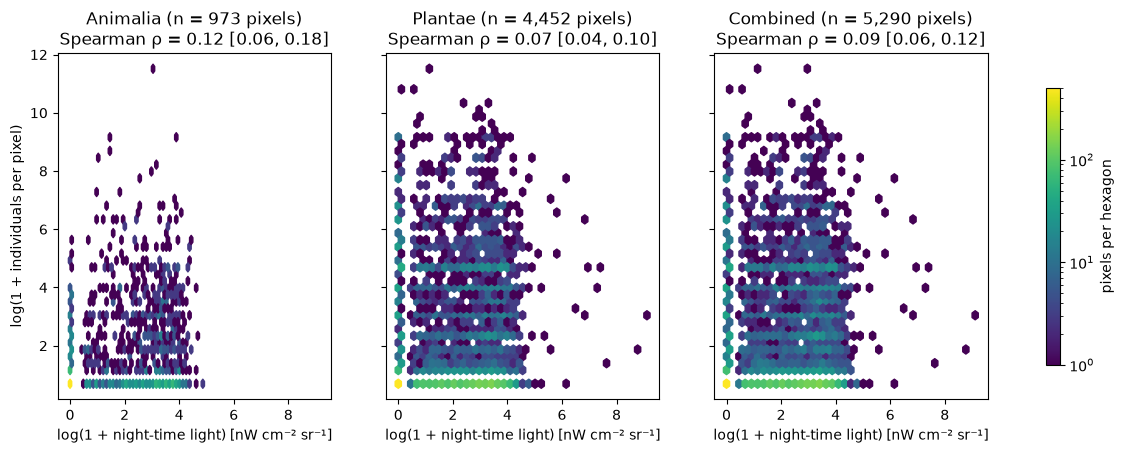

In [7]:
fig, axes = plt.subplots(1, len(GROUPS), figsize=(5 * len(GROUPS), 4.5), sharex=True, sharey=True)
for ax, group in zip(axes, GROUPS):
    x, y = occupied_pairs(group, FIGURE_MEASURE)
    hb = ax.hexbin(np.log1p(x), np.log1p(y), gridsize=40, mincnt=1, cmap="viridis", bins="log")
    row = corr.query("group == @group and measure == @FIGURE_MEASURE").iloc[0]
    ax.set_title(f"{group} (n = {x.size:,} pixels)\n"
                 f"Spearman ρ = {row.spearman_rho:.2f} [{row.rho_ci_low:.2f}, {row.rho_ci_high:.2f}]")
    ax.set_xlabel("log(1 + night-time light) [nW cm⁻² sr⁻¹]")
fig.colorbar(hb, ax=axes, label="pixels per hexagon", shrink=0.8)
axes[0].set_ylabel(f"log(1 + {FIGURE_MEASURE} per pixel)")
fig.savefig(FIG_DIR / "hexbin_nightlight_vs_counts.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Counts by night-time light class and quantile regression
Night-time light classes are defined over all pixels in Finland: unlit pixels (0) form one class
and lit pixels are split into quintiles (Q1 dimmest, Q5 brightest). The same classes are used in
step 6. Quantile regression shows whether the relationship differs between pixels with low and
high counts (e.g. the 90th percentile).

Lit quintile breaks (nW/cm²/sr): [0.88 1.28 2.22 5.47]


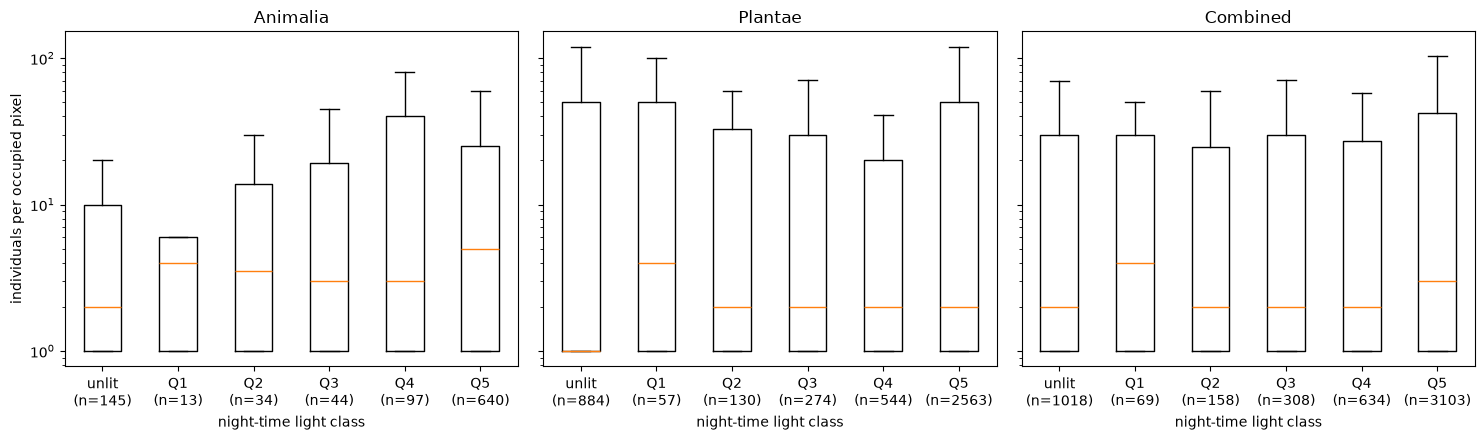

In [8]:
lit_breaks = np.quantile(nl[lit], [0.2, 0.4, 0.6, 0.8])
nl_class = np.full(nl.shape, -1)
nl_class[valid & (nl == 0)] = 0
nl_class[lit] = np.digitize(nl[lit], lit_breaks) + 1
class_labels = ["unlit"] + [f"Q{i}" for i in range(1, 6)]
print("Lit quintile breaks (nW/cm²/sr):", np.round(lit_breaks, 2))

fig, axes = plt.subplots(1, len(GROUPS), figsize=(5 * len(GROUPS), 4.5), sharey=True)
for ax, group in zip(axes, GROUPS):
    grid = counts[group][FIGURE_MEASURE]
    data = [grid[(nl_class == k) & (grid > 0)] for k in range(len(class_labels))]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(class_labels) + 1), [f"{l}\n(n={len(d)})" for l, d in zip(class_labels, data)])
    ax.set_yscale("log")
    ax.set_title(group)
    ax.set_xlabel("night-time light class")
axes[0].set_ylabel(f"{FIGURE_MEASURE} per occupied pixel")
fig.tight_layout()
fig.savefig(FIG_DIR / "counts_by_nightlight_class.png", dpi=200, bbox_inches="tight")
plt.show()

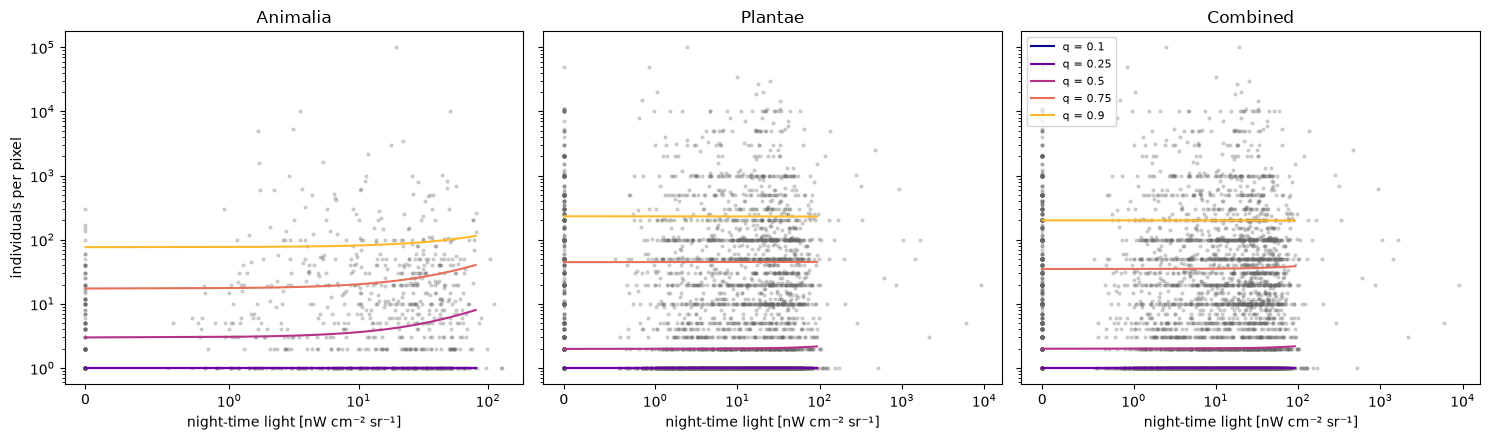

,group,measure,quantile,intercept,slope,slope_ci_low,slope_ci_high
0,Animalia,individuals,0.10,1.0000,0.0000,-0.0247,0.0247
1,Animalia,individuals,0.25,1.0000,0.0000,-0.0233,0.0233
2,Animalia,individuals,0.50,3.0000,0.0627,0.0350,0.0904
3,Animalia,individuals,0.75,17.3671,0.2875,0.1249,0.4500
4,Animalia,individuals,0.90,76.7488,0.4724,-0.6023,1.5471
5,Plantae,individuals,0.10,1.0000,0.0000,-0.0004,0.0004
6,Plantae,individuals,0.25,1.0000,0.0000,-0.0008,0.0008
7,Plantae,individuals,0.50,1.9874,0.0020,0.0002,0.0038
8,Plantae,individuals,0.75,44.8084,0.0036,-0.0135,0.0208
9,Plantae,individuals,0.90,232.0810,-0.0234,-1.3019,1.2552


In [9]:
qr_rows = []
fig, axes = plt.subplots(1, len(GROUPS), figsize=(5 * len(GROUPS), 4.5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.85, len(QUANTILES)))
for ax, group in zip(axes, GROUPS):
    x, y = occupied_pairs(group, FIGURE_MEASURE)
    X = sm.add_constant(x)
    xs = np.linspace(x.min(), np.percentile(x, 99), 200)
    ax.scatter(x, y, s=4, alpha=0.25, color="0.4", rasterized=True)
    for q, col in zip(QUANTILES, colors):
        res = sm.QuantReg(y, X).fit(q=q, max_iter=5000)
        intercept, slope = res.params
        lo, hi = res.conf_int()[1]
        qr_rows.append({"group": group, "measure": FIGURE_MEASURE, "quantile": q,
                        "intercept": intercept, "slope": slope, "slope_ci_low": lo, "slope_ci_high": hi})
        ax.plot(xs, intercept + slope * xs, color=col, lw=1.5, label=f"q = {q}")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("log")
    ax.set_title(group)
    ax.set_xlabel("night-time light [nW cm⁻² sr⁻¹]")
axes[0].set_ylabel(f"{FIGURE_MEASURE} per pixel")
axes[-1].legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "quantile_regression.png", dpi=200, bbox_inches="tight")
plt.show()

qr = pd.DataFrame(qr_rows)
qr.to_csv(RESULTS_DIR / "quantile_regression.csv", index=False)
qr.round(4)

## 6. Share of pixels with any record, by night-time light class
Steps 4 and 5 only look at pixels where something was recorded. Here all pixels in Finland are
used, with the night-time light classes from step 5.

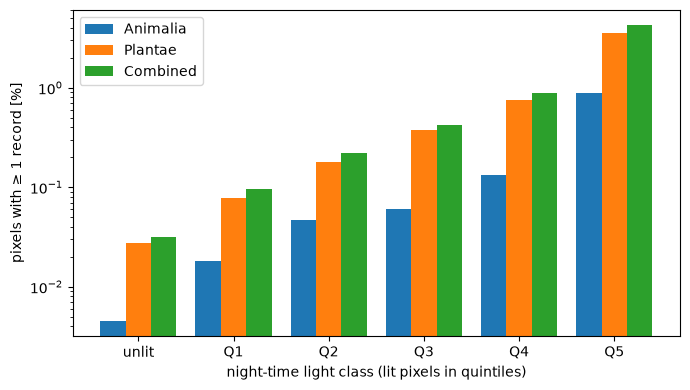

group,Animalia,Combined,Plantae
nl_class,,,
unlit,0.004,0.032,0.027
Q1,0.018,0.095,0.079
Q2,0.047,0.218,0.180
Q3,0.061,0.426,0.379
Q4,0.134,0.876,0.752
Q5,0.885,4.289,3.543


In [10]:
occ_rows = []
for group in GROUPS:
    occupied = counts[group]["records"] > 0
    for k, label in enumerate(class_labels):
        in_class = nl_class == k
        occ_rows.append({"group": group, "nl_class": label, "n_pixels": int(in_class.sum()),
                         "share_occupied": occupied[in_class].mean()})
occupancy = pd.DataFrame(occ_rows)
occupancy.to_csv(RESULTS_DIR / "occupancy_by_nightlight_class.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.8 / len(GROUPS)
for i, group in enumerate(GROUPS):
    sub = occupancy[occupancy["group"] == group]
    ax.bar(np.arange(len(class_labels)) + (i - (len(GROUPS) - 1) / 2) * width,
           sub["share_occupied"] * 100, width, label=group)
ax.set_xticks(np.arange(len(class_labels)), class_labels)
ax.set_yscale("log")
ax.set_xlabel("night-time light class (lit pixels in quintiles)")
ax.set_ylabel("pixels with ≥ 1 record [%]")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "occupancy_by_nightlight_class.png", dpi=200, bbox_inches="tight")
plt.show()
occupancy.pivot(index="nl_class", columns="group", values="share_occupied").loc[class_labels].mul(100).round(3)

## 7. Maps

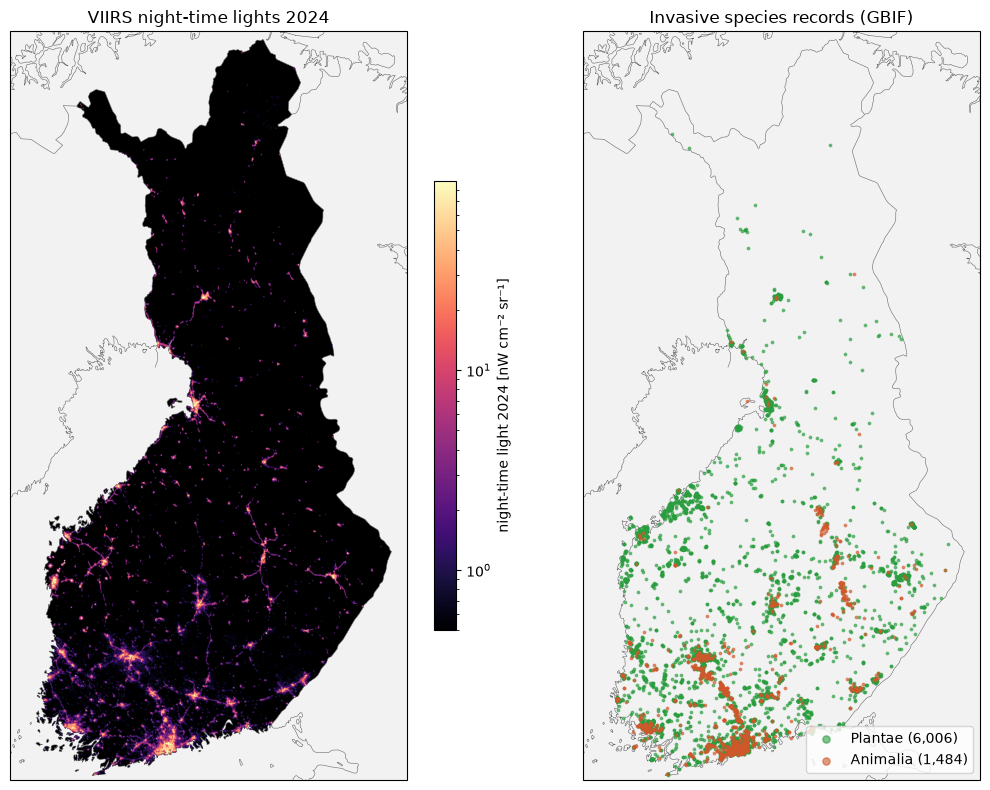

In [11]:
left, bottom = nl_transform * (0, nl.shape[0])
right, top = nl_transform * (nl.shape[1], 0)
proj = ccrs.UTM(35)
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(1, 2, figsize=(11, 8), subplot_kw={"projection": proj})
for ax in axes:
    ax.set_extent([left, right, bottom, top], crs=data_crs)
    ax.add_feature(cfeature.OCEAN, facecolor="#dfe9f2", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")

ax = axes[0]
ax.add_geometries(boundary.to_crs("EPSG:4326").geometry, crs=data_crs, facecolor="black", edgecolor="none", zorder=1)
im = ax.imshow(np.ma.masked_where(~lit, nl), origin="upper", extent=(left, right, bottom, top),
               transform=data_crs, cmap="magma", norm=LogNorm(vmin=0.5, vmax=np.percentile(nl[lit], 99.5)), zorder=2)
fig.colorbar(im, ax=ax, shrink=0.6, label="night-time light 2024 [nW cm⁻² sr⁻¹]")
ax.set_title("VIIRS night-time lights 2024")

ax = axes[1]
for kingdom, col in (("Plantae", "#2a9d3f"), ("Animalia", "#d0582b")):
    sub = pts[pts["kingdom"] == kingdom].to_crs("EPSG:4326")
    ax.scatter(sub.geometry.x, sub.geometry.y, s=3, alpha=0.6, color=col, transform=data_crs,
               label=f"{kingdom} ({len(sub):,})", zorder=2)
ax.legend(loc="lower right", markerscale=3)
ax.set_title("Invasive species records (GBIF)")

fig.tight_layout()
fig.savefig(FIG_DIR / "maps_nightlight_and_records.png", dpi=200, bbox_inches="tight")
plt.show()

## Interpretation and limitations

- **Sampling effort.** The records are opportunistic citizen-science observations
  (`HUMAN_OBSERVATION`). People record species where they live and move, so night-time light
  measures observer effort as much as invasion pressure. A positive association cannot be read as
  "invasive species prefer urban areas" without correcting for effort, e.g. by using records of
  all (native) species as a background.
- **Conditioning on presence.** Steps 4–5 use only pixels with at least one record. Step 6 adds
  the presence/absence view, but absence of records is not absence of species.
- **individualCount.** The field is missing for many records (set to 1) and some values are rough
  estimates up to 100,000. Results for *individuals* are therefore less reliable than those for
  *records*.
- **Time mismatch.** Records span several years, while night-time light is the 2024 composite.
- **Pixel size.** At 15 arc-seconds and 60–70° N, pixels are roughly 160–230 m east–west and
  460 m north–south, so they are smaller and less square than at the equator.

## Data sources

Please cite the original datasets if you reuse this work.

| Dataset | File | Citation |
|---|---|---|
| VIIRS Nighttime Lights (VNL) v2, annual 2024, *average_masked* | `VNL_npp_2024_global_vcmslcfg_v2_c202502261200.average_masked.dat.tif` | Elvidge, C.D., Zhizhin, M., Ghosh, T., Hsu, F.-C., Taneja, J. (2021). Annual time series of global VIIRS nighttime lights derived from monthly averages: 2012 to 2019. *Remote Sensing* 13(5), 922. https://doi.org/10.3390/rs13050922. Data: Earth Observation Group, Payne Institute for Public Policy, Colorado School of Mines, https://eogdata.mines.edu/products/vnl/ |
| Finnish invasive species observations | `invasive.csv` | Finnish Biodiversity Information Facility (FinBIF). Finnish invasive species observations. Occurrence dataset https://doi.org/10.15468/7bwhuf, accessed via GBIF.org. CC BY 4.0. |
| Country boundary (Finland) | `fi_shape/fi.shp` | simplemaps, https://simplemaps.com |
| Coastlines and borders (maps) | via Cartopy | Natural Earth, https://www.naturalearthdata.com (public domain) |